# 00 · 퍼셉트론과 논리 게이트

**출발점.** 신경망에서 가장 단순한 것 하나부터 시작한다.

이 노트북이 보여주려는 것은 하나다.

> **XOR 같은 비선형 게이트는 단층 퍼셉트론으로 만들 수 없고, 층을 쌓아야만 만들 수 있다.**

이것이 "깊은" 신경망이 필요한 이유의 원형이다. 대수적으로 증명하고,
실제로 학습을 돌려 실패하는 것을 보고, 층을 쌓아 해결한 다음,
**왜** 층을 쌓으면 되는지를 그림으로 확인한다.

이후 노트북은 코세라 [Deep Learning Specialization](https://www.coursera.org/specializations/deep-learning)의
순서를 따라간다. 전체 계획은 [docs/CURRICULUM.md](../docs/CURRICULUM.md).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from src.utils import COLOR_ACCENT, COLOR_NEG, COLOR_POS, setup_plots

# 그림 설정은 여기 한 번만. 폰트, 크기, 격자, 색, 여백이 모두 잡힌다.
setup_plots()
np.set_printoptions(precision=3, suppress=True)

# 두 개의 이진 입력으로 만들 수 있는 네 가지 조합
INPUTS = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
print(INPUTS)

[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]


---

## 1. 퍼셉트론

입력에 가중치를 곱해 더하고, 임계값을 넘으면 1을 낸다.

$$
y = \begin{cases}
1 & \text{if } \; w_1x_1 + w_2x_2 + b > 0 \\
0 & \text{otherwise}
\end{cases}
$$

벡터로 쓰면 $y = \text{step}(w \cdot x + b)$ 이다. $b$는 **편향(bias)** 으로,
얼마나 쉽게 1을 내보낼지를 조절한다. $b$가 크면 잘 켜지고, 작으면 잘 안 켜진다.

기하학적으로 $w \cdot x + b = 0$ 은 **직선**(일반적으로 초평면)이고,
퍼셉트론은 그 직선의 어느 쪽에 점이 있는지를 답한다.
그래서 퍼셉트론이 표현할 수 있는 것은 **직선 하나로 갈라지는 문제**뿐이다.
이 사실 하나가 이 노트북 전체의 결론을 만든다.

In [2]:
class Perceptron:
    # 단층 퍼셉트론. y = step(w·x + b)

    def __init__(self, w, b):
        self.w = np.asarray(w, dtype=float)
        self.b = float(b)

    def __call__(self, x):
        # x: (2,) 하나 또는 (N, 2) 배치 — 둘 다 받는다
        z = np.atleast_2d(x) @ self.w + self.b
        y = (z > 0).astype(int)
        return y[0] if np.ndim(x) == 1 else y

    def truth_table(self, inputs=INPUTS):
        return self(inputs)

    def __repr__(self):
        return f"Perceptron(w={self.w}, b={self.b:g})"

def show_table(name, gate, inputs=INPUTS):
    out = gate(inputs)
    rows = "  ".join(f"({int(a)},{int(b)})→{o}" for (a, b), o in zip(inputs, out))
    print(f"{name:<6s} {rows}")
    return out

p = Perceptron(w=[0.5, 0.5], b=-0.7)
print(p)
show_table("test", p);

Perceptron(w=[0.5 0.5], b=-0.7)
test   (0,0)→0  (0,1)→0  (1,0)→0  (1,1)→1


---

## 2. 게이트 만들기

가중치를 **손으로** 정해 논리 게이트를 만든다. 아직 학습은 없다.

- **AND**: 둘 다 1일 때만 1. 둘을 더한 값이 2일 때만 넘도록 임계값을 1과 2 사이에 둔다.
- **OR**: 하나라도 1이면 1. 임계값을 0과 1 사이에 둔다.
- **NAND**: AND의 반대. 가중치와 편향의 **부호를 전부 뒤집으면** 된다.

가중치는 유일하지 않다. `AND = Perceptron([0.5, 0.5], -0.7)` 도 되고
`Perceptron([1, 1], -1.5)` 도 된다. 부등식만 만족하면 무엇이든 된다.

In [3]:
AND  = Perceptron(w=[0.5, 0.5], b=-0.7)
OR   = Perceptron(w=[0.5, 0.5], b=-0.2)
NAND = Perceptron(w=[-0.5, -0.5], b=0.7)     # AND의 부호를 뒤집은 것

print("입력          (0,0) (0,1) (1,0) (1,1)")
print("-" * 46)
for name, gate in [("AND", AND), ("OR", OR), ("NAND", NAND)]:
    show_table(name, gate)

# 기대하는 진리표와 대조
assert np.array_equal(AND.truth_table(),  [0, 0, 0, 1])
assert np.array_equal(OR.truth_table(),   [0, 1, 1, 1])
assert np.array_equal(NAND.truth_table(), [1, 1, 1, 0])
print("\n세 게이트 모두 정확")

입력          (0,0) (0,1) (1,0) (1,1)
----------------------------------------------
AND    (0,0)→0  (0,1)→0  (1,0)→0  (1,1)→1
OR     (0,0)→0  (0,1)→1  (1,0)→1  (1,1)→1
NAND   (0,0)→1  (0,1)→1  (1,0)→1  (1,1)→0

세 게이트 모두 정확


### 그림으로 — 직선이 네 점을 어떻게 가르는가

$w \cdot x + b = 0$ 을 그려 보면, 퍼셉트론이 하는 일이 **직선 긋기**임이 분명해진다.

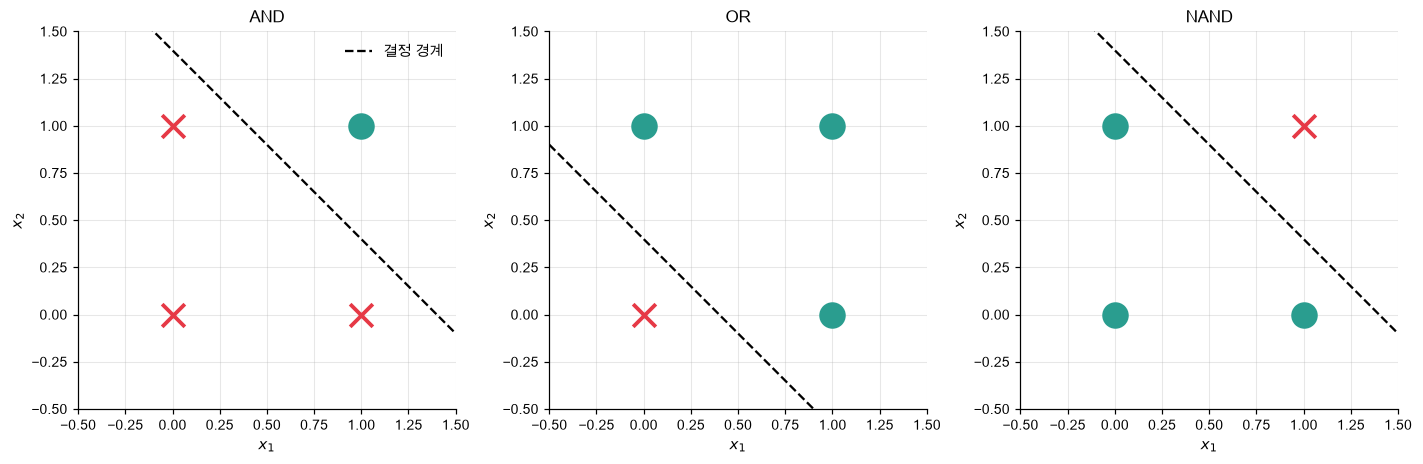

● = 출력 1,  ✕ = 출력 0
세 경우 모두 직선 하나로 ●와 ✕를 완전히 갈라놓을 수 있다.


In [4]:
def plot_gate(gate, labels, ax, title):
    # 결정 직선 w1·x1 + w2·x2 + b = 0 을 x2 에 대해 풀어 그린다
    xs = np.linspace(-0.5, 1.5, 100)
    w1, w2 = gate.w
    if abs(w2) > 1e-12:
        ax.plot(xs, -(w1 * xs + gate.b) / w2, "k--", lw=1.5, label="결정 경계")
    for (x1, x2), t in zip(INPUTS, labels):
        ax.scatter(x1, x2, s=220, marker="o" if t else "x",
                   c=COLOR_POS if t else COLOR_NEG, linewidths=2.5, zorder=3)
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_title(title); ax.set_aspect("equal")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (name, gate, labels) in zip(axes, [
        ("AND", AND, [0, 0, 0, 1]), ("OR", OR, [0, 1, 1, 1]), ("NAND", NAND, [1, 1, 1, 0])]):
    plot_gate(gate, labels, ax, name)
axes[0].legend(loc="upper right")
plt.show()

print("● = 출력 1,  ✕ = 출력 0")
print("세 경우 모두 직선 하나로 ●와 ✕를 완전히 갈라놓을 수 있다.")

---

## 3. XOR — 단층으로는 불가능하다

XOR(배타적 논리합)은 **둘 중 하나만** 1일 때 1이다.

| $x_1$ | $x_2$ | XOR |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | 0 |

먼저 그림으로 보자. ●를 ✕에서 갈라놓는 직선을 그을 수 있는가?

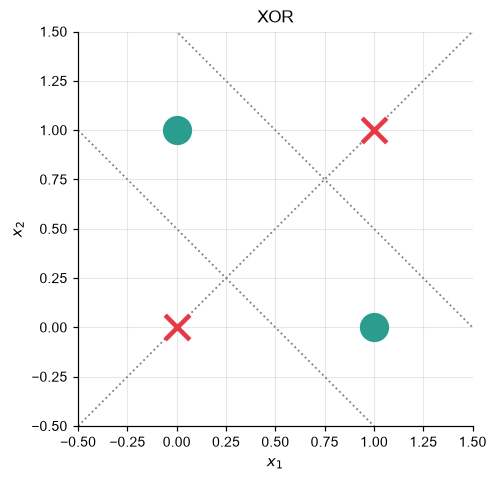

● 두 개가 대각선으로 마주보고, ✕ 두 개도 대각선으로 마주본다.
어떤 직선을 그어도 한쪽에 ●와 ✕가 섞인다.


In [5]:
fig, ax = plt.subplots(figsize=(4.6, 4.6))
for (x1, x2), t in zip(INPUTS, [0, 1, 1, 0]):
    ax.scatter(x1, x2, s=260, marker="o" if t else "x",
               c=COLOR_POS if t else COLOR_NEG, linewidths=3, zorder=3)
# 시도해 볼 만한 직선 몇 개
for w, b, style in [((1, 1), -0.5, ":"), ((1, 1), -1.5, ":"), ((1, -1), 0.0, ":")]:
    xs = np.linspace(-0.5, 1.5, 50)
    ax.plot(xs, -(w[0] * xs + b) / w[1], style, c="gray", lw=1.2)
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5); ax.set_aspect("equal")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_title("XOR")
plt.show()

print("● 두 개가 대각선으로 마주보고, ✕ 두 개도 대각선으로 마주본다.")
print("어떤 직선을 그어도 한쪽에 ●와 ✕가 섞인다.")

### 증명

그림은 설득이지 증명이 아니다. 대수적으로 보인다.
XOR을 내는 $(w_1, w_2, b)$가 존재한다고 가정하자. 네 점 각각이 조건을 준다.

$$
\begin{aligned}
(0,0) \to 0 &: \quad b \le 0 &&\cdots(1)\\
(1,0) \to 1 &: \quad w_1 + b > 0 &&\cdots(2)\\
(0,1) \to 1 &: \quad w_2 + b > 0 &&\cdots(3)\\
(1,1) \to 0 &: \quad w_1 + w_2 + b \le 0 &&\cdots(4)
\end{aligned}
$$

(2)와 (3)을 더하면

$$ w_1 + w_2 + 2b > 0 \quad\Longrightarrow\quad w_1 + w_2 + b > -b $$

그런데 (1)에서 $b \le 0$, 즉 $-b \ge 0$ 이므로

$$ w_1 + w_2 + b > -b \ge 0 $$

이는 (4)의 $w_1 + w_2 + b \le 0$ 과 **모순**이다. 따라서 그런 $(w_1, w_2, b)$는 존재하지 않는다. $\blacksquare$

핵심은 이것이 **가중치를 잘 못 찾아서가 아니라는** 점이다.
아무리 오래 학습시켜도, 어떤 최적화 알고리즘을 써도 찾을 수 없다.
표현력 자체의 한계다.

### 학습시켜 보면 — 가중치가 주기에 갇힌다

퍼셉트론 학습 규칙으로 직접 확인한다. 틀린 샘플이 있으면 그쪽으로 가중치를 밀어 준다.

$$ w \leftarrow w + \eta\,(t - y)\,x, \qquad b \leftarrow b + \eta\,(t - y) $$

AND는 몇 에폭 만에 오분류가 0이 되고 가중치가 **고정**된다.
XOR은 오분류가 0으로 내려가지 않을 뿐 아니라, 가중치가 **주기에 빠져**
매 에폭 끝마다 정확히 같은 값으로 되돌아온다. 상태가 반복되므로
1000에폭을 돌리든 100만 에폭을 돌리든 결과가 달라지지 않는다.

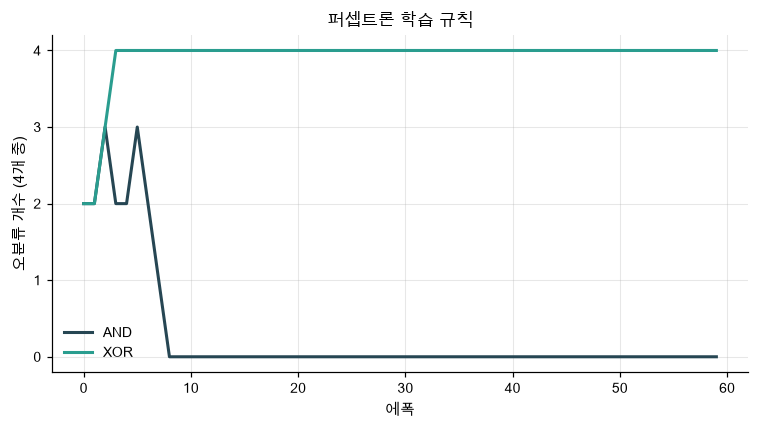

AND : 8에폭에 오분류 0 도달 후 가중치 고정
      최종 (w1, w2, b) = [ 0.213  0.187 -0.3  ]

XOR : 60에폭 내내 오분류 0에 도달하지 못함 (최솟값 2)
      20에폭 시점 (w1, w2, b) = [-0.187 -0.013  0.1  ]
      60에폭 시점 (w1, w2, b) = [-0.187 -0.013  0.1  ]
      두 상태가 완전히 동일한가: True

가중치가 같은 값으로 되돌아온다 = 주기에 갇혔다.
더 오래 돌리는 것은 같은 순환을 반복하는 것뿐이다.


In [6]:
def train_perceptron(targets, epochs=60, lr=0.1, seed=0):
    # 퍼셉트론 학습 규칙. 에폭마다 오분류 개수와 가중치 상태를 기록한다.
    rng = np.random.default_rng(seed)
    w, b = rng.standard_normal(2) * 0.1, 0.0
    errors, states = [], []
    for _ in range(epochs):
        n_wrong = 0
        for x, t in zip(INPUTS, targets):
            y = int(x @ w + b > 0)
            if y != t:
                n_wrong += 1
                w = w + lr * (t - y) * x
                b = b + lr * (t - y)
        errors.append(n_wrong)
        states.append(np.append(w, b))          # 에폭이 끝난 시점의 (w1, w2, b)
    return errors, np.array(states)

and_err, and_st = train_perceptron([0, 0, 0, 1])
xor_err, xor_st = train_perceptron([0, 1, 1, 0])

fig, ax = plt.subplots()
ax.plot(and_err, label="AND", lw=2)
ax.plot(xor_err, label="XOR", lw=2)
ax.set_xlabel("에폭"); ax.set_ylabel("오분류 개수 (4개 중)")
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_title("퍼셉트론 학습 규칙"); ax.legend()
plt.show()

print(f"AND : {and_err.index(0)}에폭에 오분류 0 도달 후 가중치 고정")
print(f"      최종 (w1, w2, b) = {and_st[-1]}")
print()
print(f"XOR : 60에폭 내내 오분류 0에 도달하지 못함 (최솟값 {min(xor_err)})")
print(f"      20에폭 시점 (w1, w2, b) = {xor_st[19]}")
print(f"      60에폭 시점 (w1, w2, b) = {xor_st[59]}")
print(f"      두 상태가 완전히 동일한가: {np.array_equal(xor_st[19], xor_st[59])}")
print()
print("가중치가 같은 값으로 되돌아온다 = 주기에 갇혔다.")
print("더 오래 돌리는 것은 같은 순환을 반복하는 것뿐이다.")

---

## 4. 층을 쌓으면 된다

XOR은 이미 알고 있는 게이트들의 **조합**으로 쓸 수 있다.

$$ \mathrm{XOR}(x_1, x_2) = \mathrm{AND}\big(\mathrm{OR}(x_1,x_2),\; \mathrm{NAND}(x_1,x_2)\big) $$

말로 풀면 "**하나라도 켜져 있고**(OR), **둘 다 켜져 있지는 않은**(NAND) 경우"다.

구조를 보면 **2층**이다.

```
x1 ─┬─→ [OR]   ─┐
    │            ├─→ [AND] ─→ y
x2 ─┴─→ [NAND] ─┘
     은닉층        출력층
```

In [7]:
def XOR(x):
    h1 = OR(x)                                  # 은닉 뉴런 1
    h2 = NAND(x)                                # 은닉 뉴런 2
    h = np.stack([h1, h2], axis=-1).astype(float)
    return AND(h)                               # 출력 뉴런

print("입력          (0,0) (0,1) (1,0) (1,1)")
print("-" * 46)
show_table("XOR", XOR)
assert np.array_equal(XOR(INPUTS), [0, 1, 1, 0])
print("\n정확 — 단층으로 불가능하던 것이 2층으로 풀렸다")

입력          (0,0) (0,1) (1,0) (1,1)
----------------------------------------------
XOR    (0,0)→0  (0,1)→1  (1,0)→1  (1,1)→0

정확 — 단층으로 불가능하던 것이 2층으로 풀렸다


---

## 5. 왜 되는가 — 은닉층은 좌표를 바꾼다

출력층도 결국 퍼셉트론 하나다. 직선밖에 못 긋는다.
그런데 어떻게 직선으로 못 가르던 문제가 풀렸을까?

**출력층이 보는 것은 원래 입력 $(x_1, x_2)$가 아니라 은닉층의 출력 $(h_1, h_2)$이기 때문이다.**

은닉층이 네 점을 어디로 옮기는지 보자.

| $(x_1,x_2)$ | $h_1 = \mathrm{OR}$ | $h_2 = \mathrm{NAND}$ | XOR |
|:---:|:---:|:---:|:---:|
| (0,0) | 0 | 1 | 0 |
| (0,1) | 1 | 1 | **1** |
| (1,0) | 1 | 1 | **1** |
| (1,1) | 1 | 0 | 0 |

$(0,1)$과 $(1,0)$이 **같은 점 $(1,1)$로 겹쳐졌다**.
원래 공간에서 대각선으로 마주보던 두 ●가 한 점이 된 것이다.
그러면 남은 세 점은 직선 하나로 갈라진다 — 그게 바로 AND다.

**이것이 깊이의 의미다.** 층을 쌓는 것은 표현력을 "조금 늘리는" 게 아니라,
**문제를 선형분리 가능한 좌표계로 옮기는 것**이다.
앞으로 나오는 모든 신경망이 하는 일이 이것의 연속이다.

findfont: Failed to find font weight bold, now using 400.


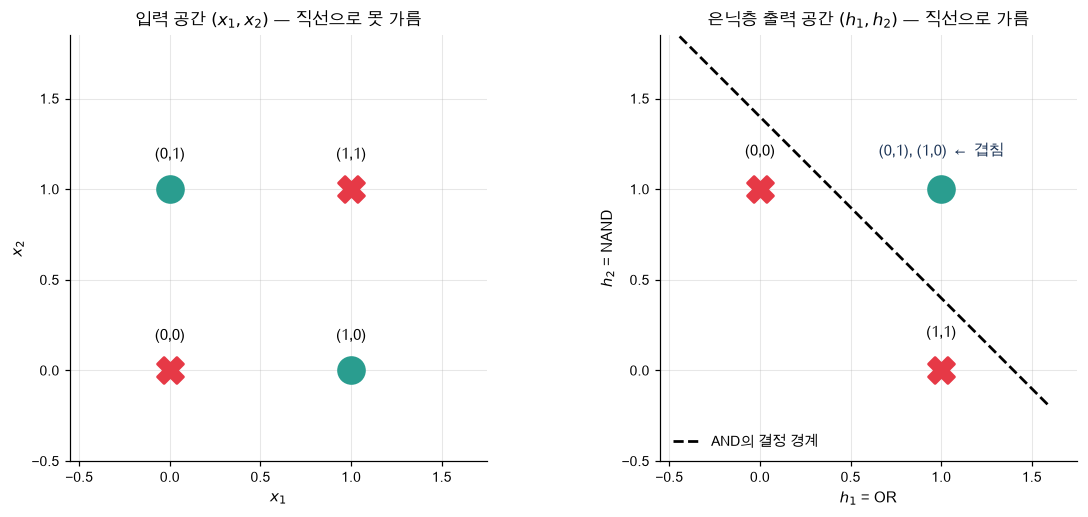

네 점이 세 점이 되었다 — 입력 (0,1)과 (1,0)이 같은 자리 (1,1)로 겹쳤다.
겹치고 나면 남은 세 점은 직선 하나로 갈린다. 그 직선이 곧 AND다.


In [8]:
H = np.stack([OR(INPUTS), NAND(INPUTS)], axis=-1).astype(float)
labels = np.array([0, 1, 1, 0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# ---- 왼쪽: 원래 입력 공간 ----
for (x1, x2), t in zip(INPUTS, labels):
    axes[0].scatter(x1, x2, s=280, marker="o" if t else "X",
                    c=COLOR_POS if t else COLOR_NEG, linewidths=2, zorder=3)
    axes[0].annotate(f"({int(x1)},{int(x2)})", (x1, x2),
                     textcoords="offset points", xytext=(0, 20),
                     ha="center", fontsize=10)
axes[0].set_title("입력 공간 $(x_1, x_2)$ — 직선으로 못 가름")
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$")

# ---- 오른쪽: 은닉층 출력 공간 ----
# 서로 다른 입력이 같은 h 로 겹치므로, 겹친 것끼리 묶어 한 점에 함께 표기한다.
groups = {}
for src, h, t in zip(INPUTS, H, labels):
    groups.setdefault(tuple(h), {"srcs": [], "label": t})["srcs"].append(
        f"({int(src[0])},{int(src[1])})")

for (h1, h2), g in groups.items():
    t = g["label"]
    axes[1].scatter(h1, h2, s=280, marker="o" if t else "X",
                    c=COLOR_POS if t else COLOR_NEG, linewidths=2, zorder=3)
    text = ", ".join(g["srcs"])
    merged = len(g["srcs"]) > 1
    axes[1].annotate(text + ("  ←  겹침" if merged else ""), (h1, h2),
                     textcoords="offset points", xytext=(0, 22), ha="center",
                     fontsize=10, fontweight="bold" if merged else "normal",
                     color=COLOR_ACCENT if merged else "black")

xs = np.linspace(-0.5, 1.6, 50)
axes[1].plot(xs, -(AND.w[0] * xs + AND.b) / AND.w[1], "k--", lw=1.8,
             label="AND의 결정 경계")
axes[1].legend(loc="lower left")
axes[1].set_title("은닉층 출력 공간 $(h_1, h_2)$ — 직선으로 가름")
axes[1].set_xlabel("$h_1$ = OR"); axes[1].set_ylabel("$h_2$ = NAND")

for ax in axes:
    ax.set_xlim(-0.55, 1.75); ax.set_ylim(-0.5, 1.85); ax.set_aspect("equal")
plt.show()

print("네 점이 세 점이 되었다 — 입력 (0,1)과 (1,0)이 같은 자리 (1,1)로 겹쳤다.")
print("겹치고 나면 남은 세 점은 직선 하나로 갈린다. 그 직선이 곧 AND다.")

---

## 6. 여기서 막히는 것 — 다음 노트북으로 가는 이유

XOR은 풀었지만, **가중치를 전부 손으로 정했다**. 진짜 문제에서는 불가능하다.
학습으로 찾아야 하는데, 퍼셉트론에는 두 가지 걸림돌이 있다.

**1. 계단함수는 미분이 쓸모없다.**

$$ \frac{d}{dz}\,\mathrm{step}(z) = 0 \quad (z \ne 0), \qquad z = 0 \text{ 에서는 정의되지 않음} $$

기울기가 거의 어디서나 0이라, 경사하강이 움직일 방향을 알려주지 못한다.
위에서 쓴 퍼셉트론 학습 규칙은 경사하강이 아니라 별도의 규칙이었고,
그래서 **선형분리 가능한 문제에서만** 수렴이 보장된다.

**2. 출력이 0/1뿐이라 "얼마나 틀렸는지"를 모른다.**

정답이 1인데 0.49를 냈든 0.01을 냈든 똑같이 "틀림"이다.
학습 신호로 쓸 정보가 너무 적다.

**해법은 계단함수를 매끄러운 함수로 바꾸는 것이다.**

$$ \mathrm{step}(z) \;\longrightarrow\; \sigma(z) = \frac{1}{1 + e^{-z}} $$

시그모이드는 0과 1 사이를 부드럽게 오가고, **어디서나 미분 가능하며 도함수가 0이 아니다**.
이렇게 바꾼 뉴런 하나가 바로 **로지스틱 회귀**이고, 코세라 1강 2주차의 출발점이다.

**다음:** [`01_logistic_regression.ipynb`](01_logistic_regression.ipynb) — 뉴런 하나를 경사하강으로 학습시킨다.

---

## 7. `src/`로 정착시키기

이 노트북에서 확정된 것은 `Perceptron` 클래스 하나다.
다만 이후 노트북은 계단함수를 쓰지 않으므로, 라이브러리로 옮기지 않고
**여기 기록으로만 남긴다**. 개념적 출발점으로서의 역할이 끝났기 때문이다.

옮기는 기준은 "**앞으로 다시 쓸 것인가**"다. 그렇지 않다면 노트북에 두는 편이 낫다.